In [1]:
# Load the required libraries
import os
from typing import List
import random
import pickle
import tqdm
import gseapy as gp

import colorcet as cc

import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib import style
import datetime
from perturbgen.configs import ROOT

from adjustText import adjust_text

Set seed below and define base directory

In [2]:
date = datetime.datetime.now().strftime("%Y%m%d")

In [3]:
np.random.seed(42)
random.seed(42)

In [4]:
os.chdir(ROOT)
print(f'Current working directory: {os.getcwd()}')

Current working directory: /lustre/scratch126/cellgen/lotfollahi/kl11


In [5]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)

In [6]:
res_dir = 'T_perturb/res/hspc/fig3'
# create directaory if it does not exist
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

### 1. Data Preprocessing

In [7]:
adata_clustered = sc.read_h5ad('T_perturb/res/hspc/perturbation_5k_res/summary_plots/20250723_leiden_pert_cls.h5ad')

In [8]:
# load GATA1 perturbed cells
adata = sc.read_h5ad('/lustre/scratch126/cellgen/lotfollahi/kl11/data/hspc/cd34.h5ad')

#### 1.1 Figure 3b, Cell type annotation UMAP

<Axes: title={'center': 'celltype_v2'}, xlabel='UMAP1', ylabel='UMAP2'>

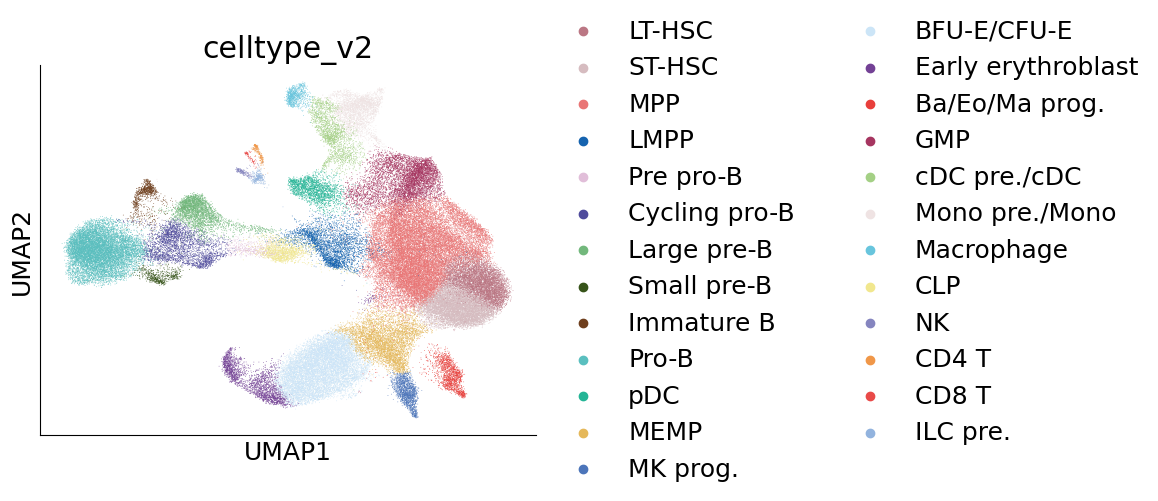

In [9]:
sc.pl.umap(
    adata,
    color='celltype_v2',
    show=False,
)
# save figure
# plt.savefig(f'{res_dir}/cd34_celltypes_umap.pdf', dpi=300, bbox_inches='tight')

In [10]:
# create a dict using var_names and gene_ensembl
var_to_ensembl = dict(zip(adata.var_names, adata.var['ensembl_id']))

In [11]:
# map adata_clustered obs
adata_clustered.obs['ensembl_id'] = adata_clustered.obs['genes'].map(var_to_ensembl)

### 2. Clustering of perturbation embedding 

In [19]:
sc.pp.neighbors(adata_clustered, n_neighbors=15, use_rep='X')
sc.tl.umap(adata_clustered, random_state=42)

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# create a dictionary to store the cluster annotations
umap_df = pd.DataFrame(
    adata_clustered.obsm['X_umap'],
    index=adata_clustered.obs.index,
    columns=['UMAP1', 'UMAP2']
)
umap_df['cluster'] = adata_clustered.obs['leiden']
umap_df['genes'] = adata_clustered.obs['genes']

In [14]:
old_cluster_annot = {
    '0': 'Activated antigen-presenting myeloid cells',
    '1': 'Transcription regulation',
    '2': 'Transcription regulation',
    '3': 'Transcription regulation',
    '4': 'Transcription regulation',
    '5': 'Core transcription control',
    '6': 'Core transcription control',
    '7': 'Stress-induced early haematopoiesis',
    '8': 'TNF and lymphoid-biased haematopoiesis',
    '9': 'Cell cycle/chromatin remodelling',
    '10': 'Innate immune activation with pathogen sensing',
    '11': 'Lymphocyte activation',
    '12': 'Cell Migration',
    '13': 'Interferon-driven cytotoxic response',
    '14': 'Stress-adapted immunity',
    '15': 'Stress-adapted immunity',
    '16': 'Core transcription control',
    '17': 'Membrane remodeling and complement cascade',
    '18': 'Tissue remodelling',
    '19': 'IFN-driven T cell activation',
    '20': 'Cycling cells',
    '21': 'Antigen presentation and germinal B cell activation',
    '22': 'Myeloid Differentiation',
    '23': 'Proliferation and Macromoleule biosynthesis',
    '24': 'Cycling progenitors',
    '25': 'Core transcription control',
    '26': 'Developmental transcriptional regulation',
    '27': 'Unknown',
    '28': 'Fatty acid metabolism',
    '29': 'MegK differentiation',
    '30': 'Hemoglobin synthesis',
    '31': 'Unknown',
    '32': 'Lymphocyte activation',
    '33': 'Stress-induced granule formation'
}

In [17]:
cluster_annot = {
    '0': 'Antigen processing and presentation',
    '1': 'Core transcription regulation',
    '2': 'Protein modification and cellular organization',
    '3': 'Protein ubiquitination and vesicle transport',
    '4': 'Vesicle and organelle localization',
    '5': 'Core transcription regulation',
    '6': 'Core transcription regulation',
    '7': 'Early lympho-myeloid differentiation',
    '8': 'Postnatal lymphoid differentiation',
    '9': 'Pediatric HSC and lymphoid progenitor proliferation',
    '10': 'Immune response to external stimuli',
    '11': 'Lymphocyte differentiation',
    '12': 'Immune response to external stimuli',
    '13': 'Immune response to external stimuli',
    '14': 'Signaling pathways in fetal innate immune cells',
    '15': 'Core transcription regulation',
    '16': 'Core transcription regulation',
    '17': 'Myeloid leukocyte activation',
    '18': 'Hypoxia-1',
    '19': 'Lymphocyte activation-1',
    '20': 'Fetal hematopoietic progenitor proliferation',
    '21': 'Antigen presentation and immune response',
    '22': 'Myeloid Differentiation',
    '23': 'Mitotic cell cycle',
    '24': 'Fetal hematopoietic progenitor proliferation',
    '25': 'Core transcription regulation',
    '26': 'Core transcription regulation',
    '27': 'Protein transport',
    '28': 'Hypoxia-2',
    '29': 'Early megakaryocyte - erythroid differentiation',
    '30': 'Fetal megakaryocyte - erythroid maturation',
    '31': 'NF-kB signaling and B cell activation',
    '32': 'Lymphocyte activation-2',
    '33': 'Fetal hemostasis and platelet activation'
}
# remap the cluster annotations
umap_df['GP_name'] = umap_df['cluster'].map(cluster_annot)
# fill rest of the values with 'Other'
umap_df['GP_name'] = umap_df['GP_name'].fillna('Other')


In [20]:
adata_clustered.obs['GP_name_old'] = adata_clustered.obs['leiden'].map(old_cluster_annot)
adata_clustered.obs['GP_name'] = adata_clustered.obs['leiden'].map(cluster_annot)
# save as h5ad
adata_clustered.write_h5ad('T_perturb/res/hspc/perturbation_5k_res/summary_plots/20250723_leiden_pert_cls_annotated.h5ad')

In [23]:
umap_df["GP_name"].nunique()

25

#### 2.1 Figure 3d, Cluster annotation UMAP

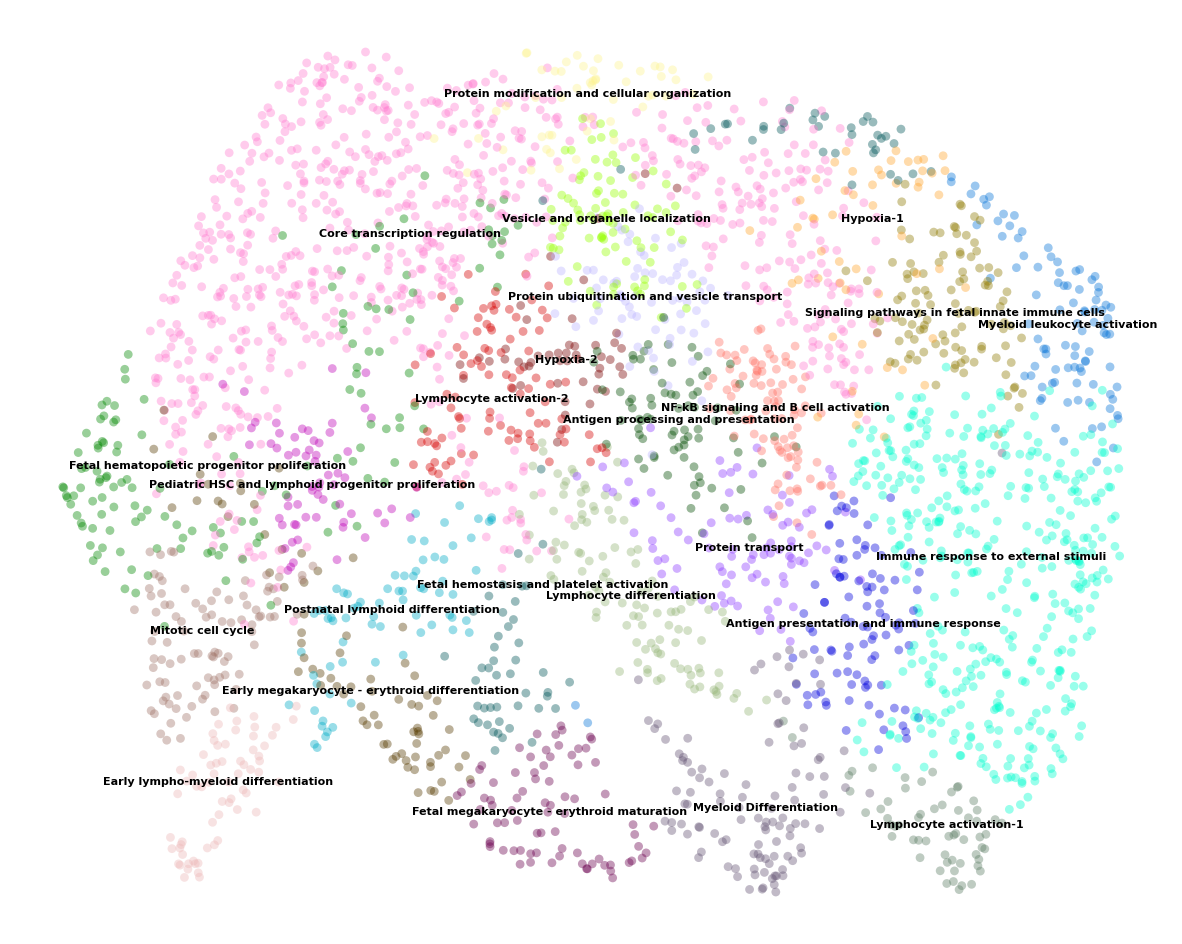

In [ ]:
plt.figure(figsize=(15, 12))


palette = cc.glasbey[:25]
# shuffle the palette
random.seed(30)  # for reproducibility
random.shuffle(palette)
# create a dictionary for the colors
color_dict = {}
for i, cluster in enumerate(umap_df["GP_name"].unique()):
    color_dict[cluster] = palette[i]


sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='GP_name', linewidth=0, alpha=0.4, 
    s=40, legend=False, palette=color_dict
)
plt.axis('off')
plt.grid(False)

# --- Cluster labels inside plot ---
for cluster, group in umap_df.groupby("GP_name"):
    x = group["UMAP1"].median()   # you can also use .mean()
    y = group["UMAP2"].median()
    plt.text(
        x, y, str(cluster),
        fontsize=8, fontweight="bold",
        ha="center", va="center",
        # bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7)
    )

# save plot
plt.savefig(f'{res_dir}/{date}_umap_full_cluster_annotation_v2_k15.pdf', bbox_inches='tight', dpi=300)

#### 2.2 Figure 3e, Meg-erythroid cluster highlighted UMAP

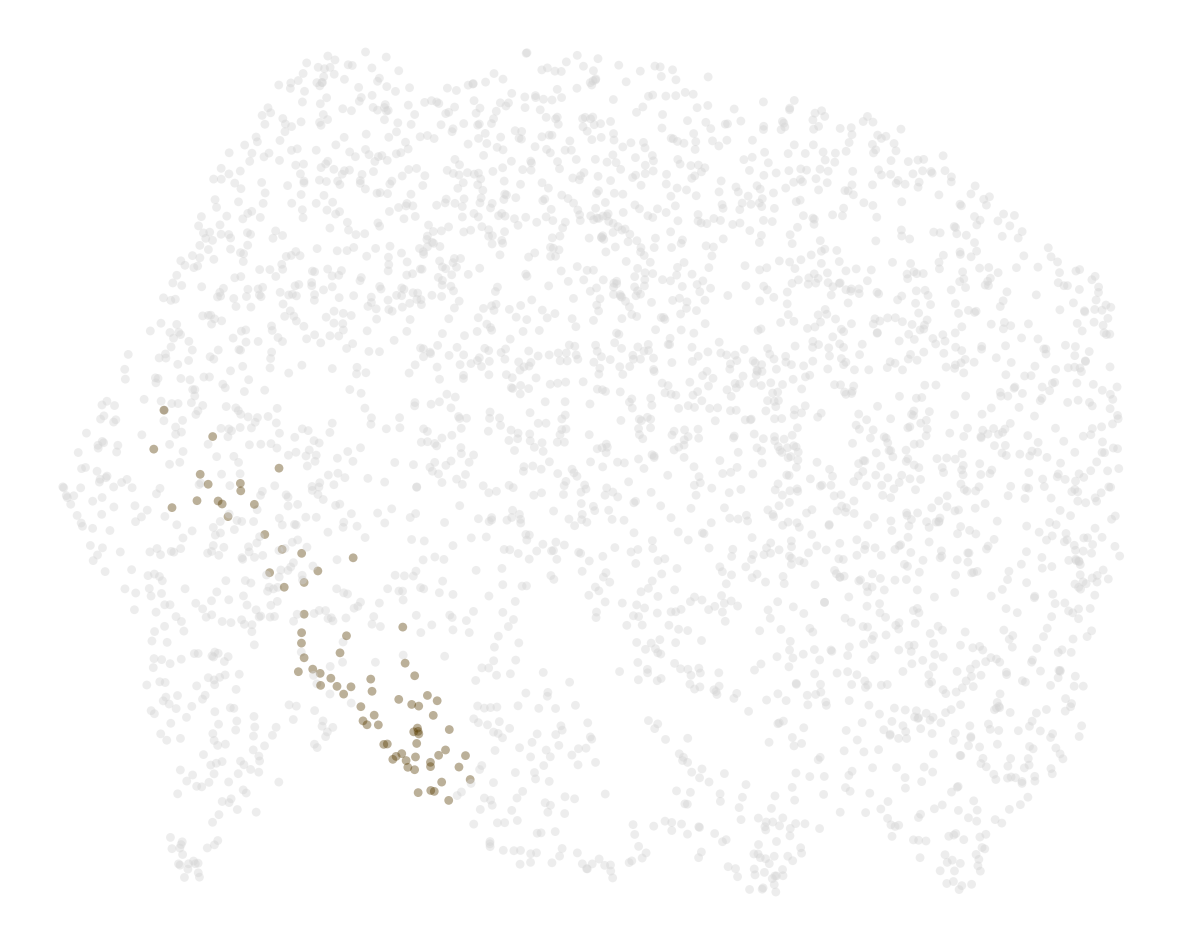

In [25]:
plt.figure(figsize=(15, 12))
# set all colors to gray in color_dict except of one
gray_dict = {k: '#D3D3D3' for k in color_dict.keys() if k != 'Early megakaryocyte - erythroid differentiation'}
gray_dict['Early megakaryocyte - erythroid differentiation'] = color_dict['Early megakaryocyte - erythroid differentiation']
# gray_dict['Fatty acid metabolism'] = color_dict['Fatty acid metabolism']
sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='GP_name', linewidth=0, alpha=0.4, 
    s=40, palette=gray_dict, legend=False
)

plt.axis('off')
plt.grid(False)

plt.savefig(f'{res_dir}/{date}_umap_megK_full_pertmap.pdf', bbox_inches='tight', dpi=300)

#### 2.2 Figure 3e, Meg-erythroid cluster marker genes

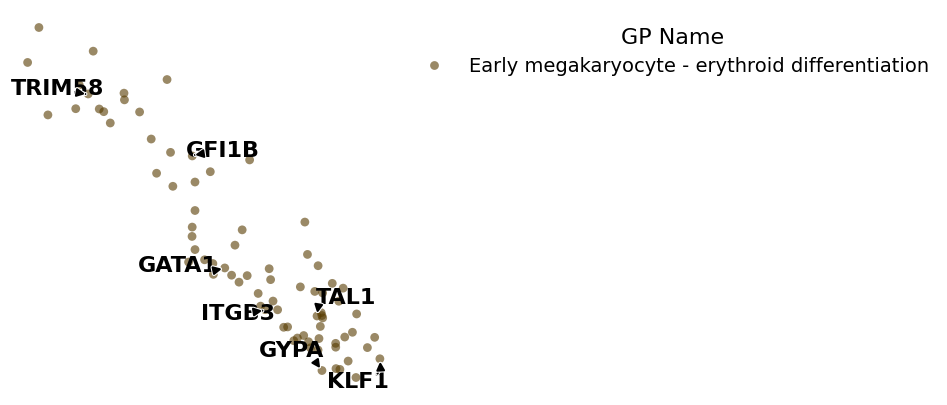

In [26]:
plt.figure(figsize=(5, 5))
megk_df = umap_df[umap_df['GP_name'] == 'Early megakaryocyte - erythroid differentiation']
sns.scatterplot(
    data=megk_df, x='UMAP1', y='UMAP2', hue='GP_name', linewidth=0, alpha=0.6, s=40,
    palette=color_dict
)
# plot legend outside of axes
plt.legend(
    loc='upper left', 
    title='GP Name',
    bbox_to_anchor=(1, 1), 
    fontsize=14, 
    title_fontsize=16
)

plt.axis('off')
plt.grid(False)
texts = []
targets = []  # to store the target positions for arrows

gene_annot = ['GFI1B', 'TAL1', 'KLF1', 'GATA1', 'GYPA', 'TRIM58', 'ITGB3']  # genes to annotate
for gene in gene_annot:
    mask = (megk_df['genes'] == gene)
    if mask.any():
        row = megk_df[mask].iloc[0]
        x, y = row['UMAP1'], row['UMAP2']

        jitter_x = x + np.random.uniform(-0.25, 0.25) 
        jitter_y = y + np.random.uniform(-0.25, 0.25) 
        
        texts.append(
            plt.text(
                jitter_x, jitter_y, gene,
                fontsize=16, fontweight='bold', 
                ha='center', va='center'
            )
        )
        targets.append((x, y))

# 3) let adjust_text move labels
adjust_text(
    texts,
    expand_points=(10,10),
    expand_text=(5, 5),
    force_points=5.0,
    force_text=5.0,
    pad=2.5,
    only_move={'points': 'xy', 'text': 'xy'},
    autoalign='xy',
    lim=1500
)

# 4) draw arrows AFTER text positions are final
ax = plt.gca()
fig = plt.gcf()
fig.canvas.draw()  # IMPORTANT: needed to get correct text extents

arrow_kw = dict(
    arrowstyle='-|>',
    mutation_scale=12,              # bigger arrow head
    lw=1.5,                         # thicker line
    color='black',
    connectionstyle="arc3,rad=0.20" # slightly less curve helps clarity
)

# Put arrows ABOVE points but BELOW text
arrow_z = 9
text_z  = 10
pad = 0.08  # in data units; increase to 0.10–0.15 if needed

for t, (x, y) in zip(texts, targets):
    bb = t.get_window_extent(renderer=fig.canvas.get_renderer())
    bb_data = bb.transformed(ax.transData.inverted())

    # text center (final, after adjust_text)
    tx, ty = t.get_position()

    # 1) closest point on the bbox to the target (x,y)
    start_x = np.clip(x, bb_data.x0, bb_data.x1)
    start_y = np.clip(y, bb_data.y0, bb_data.y1)

    # 2) push the start point OUTSIDE the bbox by 'pad'
    # direction: from target -> text center (so we go outward from the label)
    vx, vy = tx - x, ty - y
    norm = (vx**2 + vy**2)**0.5 + 1e-12
    ux, uy = vx / norm, vy / norm  # unit vector pointing from target to label

    start_x += pad * ux
    start_y += pad * uy

    arrow = FancyArrowPatch(
        (start_x, start_y), (x, y),
        **arrow_kw,
        zorder=arrow_z
    )
    arrow.set_path_effects([
        pe.Stroke(linewidth=arrow_kw["lw"] + 1.5, foreground="white"),
        pe.Normal()
    ])
    ax.add_patch(arrow)
# # save the figure
# plt.savefig(f'{res_dir}/{date}_umap_megK_annotation.pdf', bbox_inches='tight', dpi=300)

### 3. Analyze meg-erythroid cluster

In [27]:
# min expressed genes and cells same as during tokenization
sc.pp.filter_cells(adata, min_genes=1000)
sc.pp.filter_genes(adata, min_cells=10)

In [28]:
sc.tl.score_genes(
    adata,
    gene_list=megk_df.genes.unique(),
)

#### 3.1 Figure 3f, Meg-erythroid scored expression

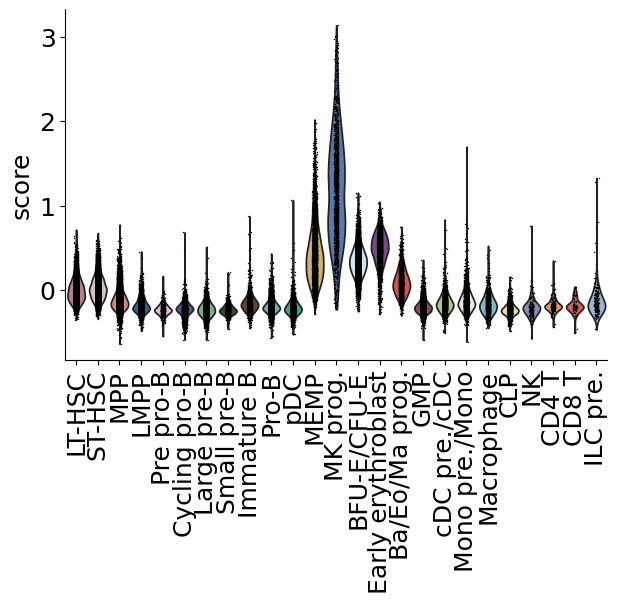

In [29]:
sc.pl.violin(
    adata,
    keys='score',
    groupby='celltype_v2',
    rotation=90,
    show=False
)
# save the figure
plt.savefig(f'{res_dir}/{date}_megK_gene_score_by_celltype_v2.pdf', bbox_inches='tight', dpi=300)

In [32]:
reactome_2024 = gp.get_library(name='Reactome_Pathways_2024', organism='Human')
go_bio = gp.get_library(name='GO_Biological_Process_2025', organism='Human')
go_cell = gp.get_library(name='GO_Cellular_Component_2025', organism='Human')
msigdb = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')

In [36]:
enr = gp.enrich(
    gene_list=megk_df.genes.unique().tolist(),
    gene_sets=[reactome_2024, go_bio, go_cell, msigdb], 
    # organism='Human', 
    cutoff=0.10,
    outdir=None,
    verbose=True,
    background = adata.var.index.tolist()
)
# assign GO enr.res2d to GO_Biological_Process_2025
enr_res = enr.results
# map Gene_set categories to actual gsea name
# map Gene_set categories to actual gsea name
# enr_res['Gene_set'] = enr_res['Gene_set'].replace({
#     'gs_ind_0': 'Reactome_Pathways_2024',
#     'gs_ind_1': 'GO_Biological_Process_2025',
#     'gs_ind_2': 'MSigDB_Hallmark_2020'
# })

2025-12-31 15:36:35,797 [INFO] Input dict object named with gs_ind_0
2025-12-31 15:36:35,812 [INFO] Input dict object named with gs_ind_1
2025-12-31 15:36:35,812 [INFO] Input dict object named with gs_ind_2
2025-12-31 15:36:35,813 [INFO] Input dict object named with gs_ind_3
2025-12-31 15:36:35,814 [INFO] Run: gs_ind_0 
2025-12-31 15:36:36,232 [INFO] Run: gs_ind_1 
2025-12-31 15:36:37,222 [INFO] Run: gs_ind_2 
2025-12-31 15:36:37,252 [INFO] Run: gs_ind_3 
2025-12-31 15:36:37,265 [INFO] Done.


In [37]:
enr_res.sort_values('Adjusted P-value', inplace=True)

In [38]:
enr_res

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
985,gs_ind_3,heme Metabolism,11/193,2.421990e-12,7.023772e-11,28.421938,760.185410,CA2;RHAG;ICAM4;MYL4;TRIM58;KLF1;TAL1;GYPE;GYPB...
161,gs_ind_0,"Platelet Activation, Signaling and Aggregation",10/259,1.153213e-09,1.435750e-07,18.668113,384.203103,GP1BA;TRPC6;GP9;SELP;THBS1;ADRA2A;SYTL4;TIMP3;...
97,gs_ind_0,Hemostasis,14/648,8.842082e-10,1.435750e-07,10.621942,221.428491,GP1BA;TRPC6;GP9;SELP;THBS1;ADRA2A;SYTL4;TIMP3;...
416,gs_ind_1,Megakaryocyte Differentiation (GO:0030219),5/18,7.693832e-10,4.885583e-07,169.883420,3565.076959,GP1BA;GP9;TAL1;MPIG6B;GATA1
445,gs_ind_1,Myeloid Cell Development (GO:0061515),4/26,5.484276e-07,1.741258e-04,82.268874,1186.005416,GP9;MPIG6B;GATA1;GP1BA
...,...,...,...,...,...,...,...,...
901,gs_ind_2,Cytoskeleton (GO:0005856),1/663,8.175655e-01,8.175655e-01,0.877294,0.176708,ARHGAP6
31,gs_ind_0,Cellular Responses to Stress,1/722,8.434779e-01,8.537643e-01,0.803991,0.136857,CLEC1B
36,gs_ind_0,Cytokine Signaling in Immune System,1/738,8.498550e-01,8.567364e-01,0.786134,0.127896,CSF2RB
3,gs_ind_0,Adaptive Immune System,1/808,8.748687e-01,8.783964e-01,0.716330,0.095760,ICAM4


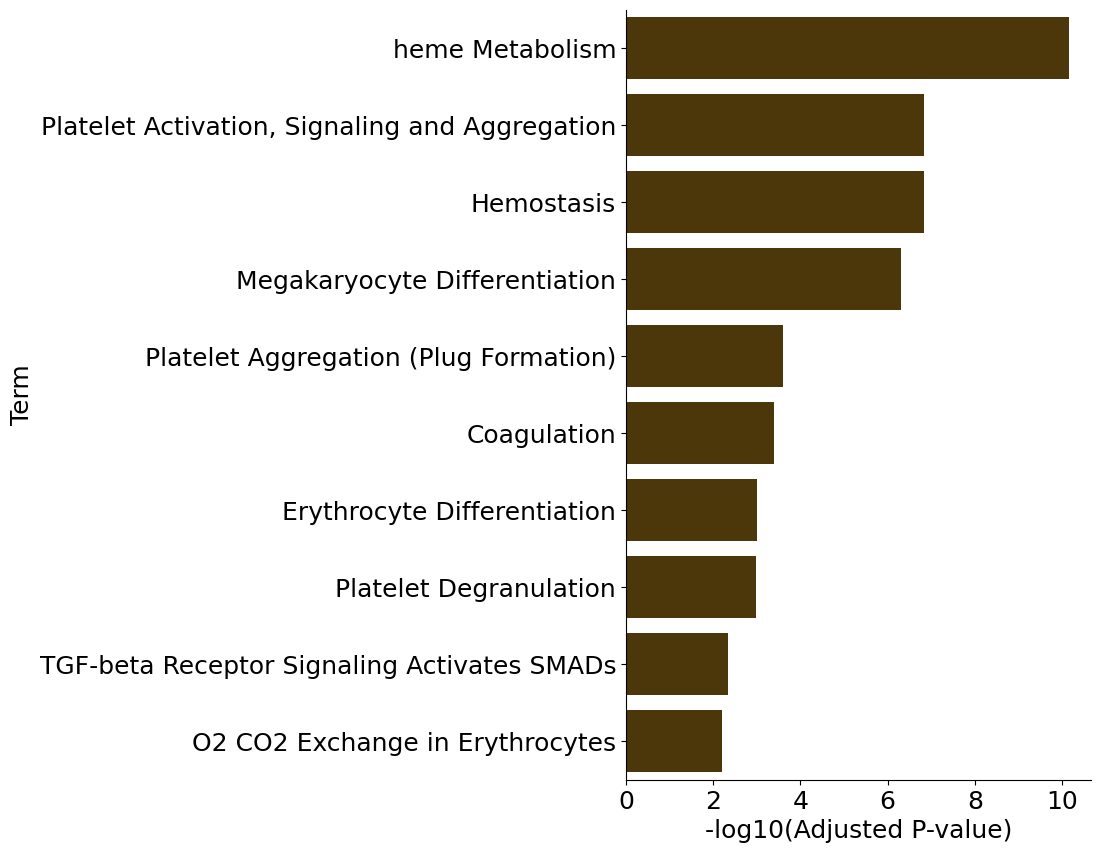

In [39]:
# filter terms to remove redundant terms
terms_to_plot = [
    'heme Metabolism',
    'Platelet Activation, Signaling and Aggregation',
    'Hemostasis',
    'Megakaryocyte Differentiation (GO:0030219)',
    'Platelet Aggregation (Plug Formation)',
    'Erythrocyte Differentiation (GO:0030218)',
    'Coagulation',
    'Platelet Degranulation',
    'O2 CO2 Exchange in Erythrocytes',
    'TGF-beta Receptor Signaling Activates SMADs',
]

enr_res_filtered = enr_res[enr_res['Term'].isin(terms_to_plot)].copy()
enr_res_filtered.sort_values('Adjusted P-value', inplace=True)
# remove GO term IDs from the Term names
enr_res_filtered['Term'] = enr_res_filtered['Term'].str.replace(r' \(GO:\d+\)', '', regex=True)
# -log 10 transform the Adjusted P-value
enr_res_filtered.loc[:,'log10_Adj_Pval'] = -np.log10(enr_res_filtered['Adjusted P-value'])
# set figure size
plt.figure(figsize=(6, 10))
sns.barplot(
    data=enr_res_filtered,
    y='Term',
    x='log10_Adj_Pval',
    color='#573b00'
)
#plot x axis as -log10 scale
plt.xlabel('-log10(Adjusted P-value)')
# save the figure
plt.savefig(f'{res_dir}/{date}_megK_gene_set_enrichment_barplot.pdf', bbox_inches='tight', dpi=300)